<a href="https://colab.research.google.com/github/Ayushi-Manjapara/CSCI218-Rice-Classification-Grp-14/blob/main/Grp14_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [2]:
pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Load the Dataset


In [4]:
rice = fetch_ucirepo(id=545)

X = rice.data.features
y = rice.data.targets

print("Dataset Shape:", X.shape)
print("Class Distribution:\n", y.value_counts())

Dataset Shape: (3810, 7)
Class Distribution:
 Class   
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


# Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF Kernel)": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# Results

In [13]:
for name, model in models.items():

    # Use scaled data for distance-based models
    if name in ["KNN (k=5)", "SVM (RBF Kernel)", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train.values.ravel())
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, precision, recall, f1])

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.916010498687664
              precision    recall  f1-score   support

      Cammeo       0.92      0.88      0.90       326
    Osmancik       0.92      0.94      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.91       762
weighted avg       0.92      0.92      0.92       762


KNN (k=5)
Accuracy: 0.9094488188976378
              precision    recall  f1-score   support

      Cammeo       0.91      0.88      0.89       326
    Osmancik       0.91      0.93      0.92       436

    accuracy                           0.91       762
   macro avg       0.91      0.91      0.91       762
weighted avg       0.91      0.91      0.91       762


SVM (RBF Kernel)
Accuracy: 0.910761154855643
              precision    recall  f1-score   support

      Cammeo       0.91      0.87      0.89       326
    Osmancik       0.91      0.94      0.92       436

    accuracy                           0.91    

# Confusion Matrix

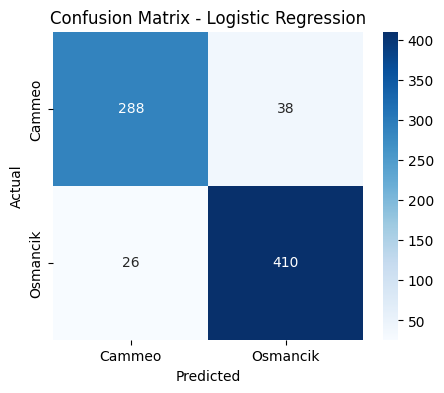

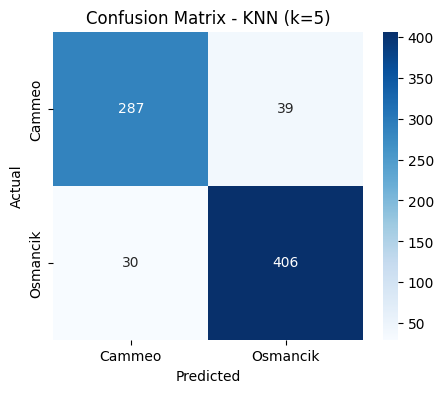

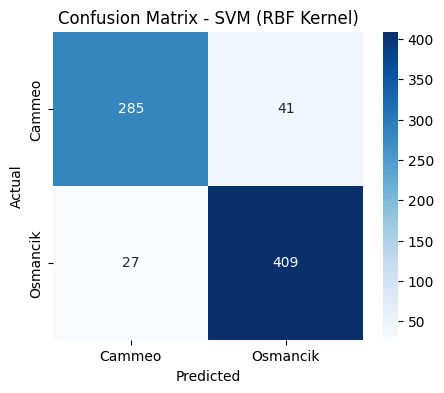

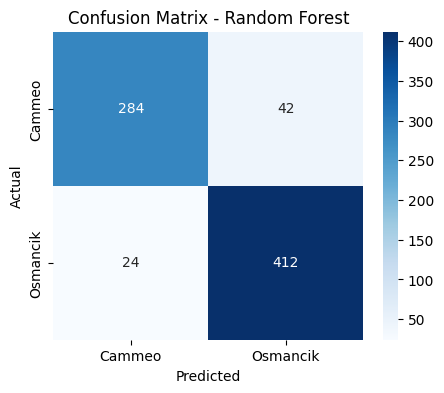

In [17]:
conf_matrices = {}

# Loop through models
for name, model in models.items():
    # Train model
    if name in ["KNN (k=5)", "SVM (RBF Kernel)", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train.values.ravel())
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm

    # Plot with color
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Cammeo", "Osmancik"],
                yticklabels=["Cammeo", "Osmancik"],
                cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Compare Results

In [10]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.916010   0.916042  0.916010  0.915793
1            KNN (k=5)  0.909449   0.909366  0.909449  0.909278
2     SVM (RBF Kernel)  0.910761   0.910845  0.910761  0.910487
3        Random Forest  0.913386   0.913730  0.913386  0.913032


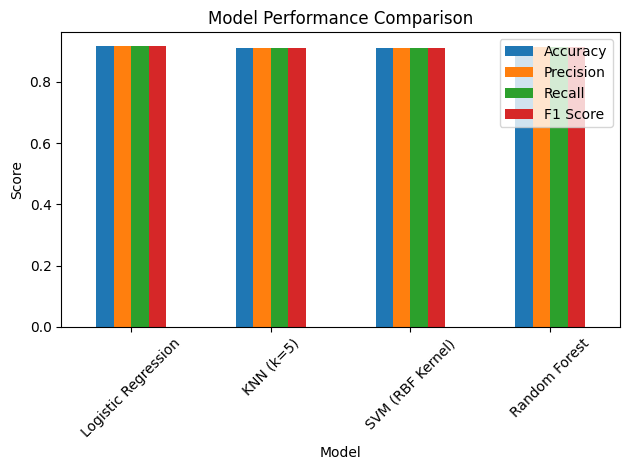

In [11]:
results_df.set_index("Model").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature Importance


Feature Importance:
             Feature  Importance
1          Perimeter    0.269484
2  Major_Axis_Length    0.266408
0               Area    0.173786
5        Convex_Area    0.132493
4       Eccentricity    0.083157
3  Minor_Axis_Length    0.042897
6             Extent    0.031776


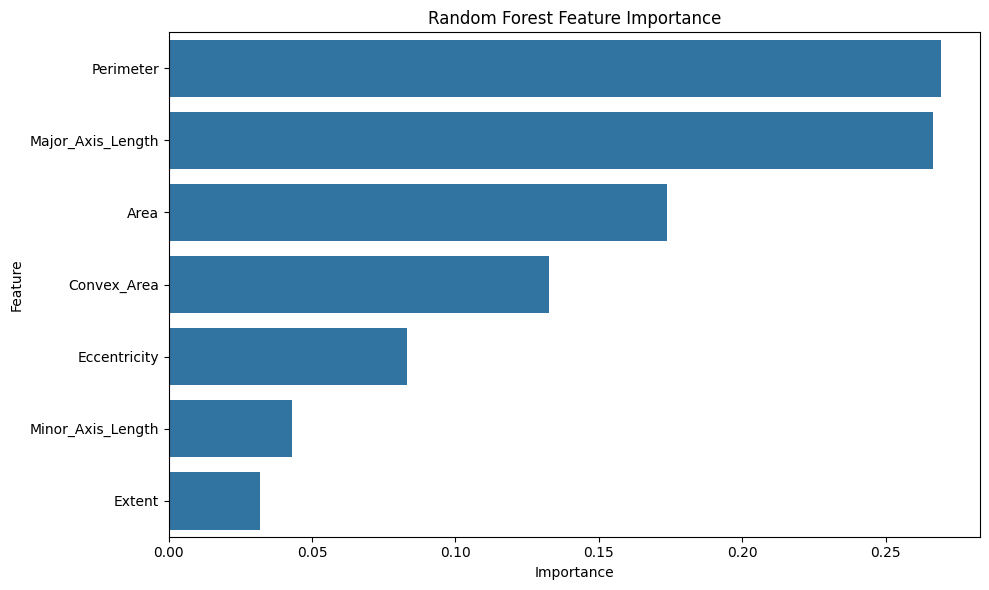

In [18]:
# Feature Importance
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train.values.ravel())

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

checking